# Day 28: Building the Most Optimized ML Pipeline
**60 Days Data Science Challenge** | Week 4 Sprint Review
**Date:** 10 June 2026
**Name:** Rajesh Yadav

---

### What I'm doing today
This is the Week 4 sprint review notebook. The idea is to take everything I've learned over Days 22-27 and combine it all into one solid, end-to-end ML pipeline.

Here's what I covered this week:

| Day | Topic |
|-----|-------|
| 22 | Sklearn Pipelines & Feature Engineering |
| 23 | Preprocessing & Validation Workflows |
| 24 | Cross-Validation & Model Selection |
| 25 | Ensemble Methods (Bagging & Boosting) |
| 26 | Hyperparameter Tuning |
| 27 | Bias-Variance Tradeoff |
| **28** | **All-in-One Optimized ML Pipeline** |

**Plan for today:**
1. Build a proper sklearn Pipeline that handles preprocessing automatically
2. Compare a few models using cross-validation to pick the best baseline
3. Tune the best model with RandomizedSearchCV
4. Evaluate on the hold-out test set
5. Check if the model is overfitting using learning curves
6. Compare with earlier days to see how much we've improved


## 1. Imports
Loading everything I need for this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import time

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    learning_curve, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost is available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found, will use GradientBoosting instead")

import sklearn
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"sklearn: {sklearn.__version__}")


XGBoost is available
numpy  : 2.2.1
pandas : 2.2.3
sklearn: 1.7.2


## 2. Load and Preprocess the Data
Using the same Telco Customer Churn dataset from Day 15 so I can compare results fairly across all the days.


In [2]:
# Find the dataset
dataset_path = None
for p in ['../day15/telco_customer_churn.csv', 'telco_customer_churn.csv']:
    if os.path.exists(p):
        dataset_path = p
        break

df_raw = pd.read_csv(dataset_path)
print(f"Shape: {df_raw.shape}")

df = df_raw.copy()

# TotalCharges has some empty strings - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
df.drop(columns=['customerID'], inplace=True)

# Split into numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Churn')
categorical_cols = df.select_dtypes(include='object').columns.tolist()

X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Numerical  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical({len(categorical_cols)}): {categorical_cols}")
print(f"\nX shape: {X.shape},  Churn rate: {y.mean():.2%}")


Shape: (7043, 21)
Numerical  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical(15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X shape: (7043, 19),  Churn rate: 26.54%


## 3. Train / Test Split
80/20 split with stratify=y to keep the same churn ratio in both sets.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  churn rate: {y_train.mean():.2%}")
print(f"Test : {X_test.shape}   churn rate: {y_test.mean():.2%}")


Train: (5634, 19)  churn rate: 26.54%
Test : (1409, 19)   churn rate: 26.54%


## 4. Build the ML Pipeline

This is the key part. Instead of manually scaling and encoding before each model, I wrap everything in a sklearn Pipeline.

How it works:
- **Numerical features**: fill missing with median → StandardScaler
- **Categorical features**: fill missing with most frequent → OneHotEncoder
- **Classifier**: sits at the end of the pipeline

The big benefit is that the scaler and encoder are only fit on training data — no data leakage. And I can pass the raw dataframe directly to fit() and predict().


In [4]:
# Preprocessing for numerical columns
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into one ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

# Helper function to quickly build a full pipeline for any model
def make_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf', model)
    ])

print("Pipeline built.")
print(f"  Numerical features  : {len(numerical_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")


Pipeline built.
  Numerical features  : 4
  Categorical features: 15


## 5. Baseline Model Comparison

Before tuning anything, I want to see how each model performs out of the box. Using 5-fold stratified cross-validation with ROC-AUC as the metric (it works well for imbalanced data like churn prediction where ~73% of customers don't churn).


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_to_test = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}
if HAS_XGB:
    models_to_test['XGBoost'] = XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0
    )

results = []
print("Running 5-fold CV on all models...\n")
t0 = time.time()

for name, model in models_to_test.items():
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results.append({
        'Model': name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std(),
    })
    print(f"  {name:<25}  AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

print(f"\nFinished in {time.time()-t0:.1f}s")
df_baseline = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
print("\n" + df_baseline.round(4).to_string(index=False))


Running 5-fold CV on all models...



  Logistic Regression        AUC = 0.8460 +/- 0.0125


  Decision Tree (d=5)        AUC = 0.8289 +/- 0.0110


  Random Forest              AUC = 0.8182 +/- 0.0123


  Gradient Boosting          AUC = 0.8479 +/- 0.0121


  XGBoost                    AUC = 0.8222 +/- 0.0086

Finished in 22.9s

              Model  CV Mean  CV Std
  Gradient Boosting   0.8479  0.0121
Logistic Regression   0.8460  0.0125
Decision Tree (d=5)   0.8289  0.0110
            XGBoost   0.8222  0.0086
      Random Forest   0.8182  0.0123


### Baseline CV Results — Chart


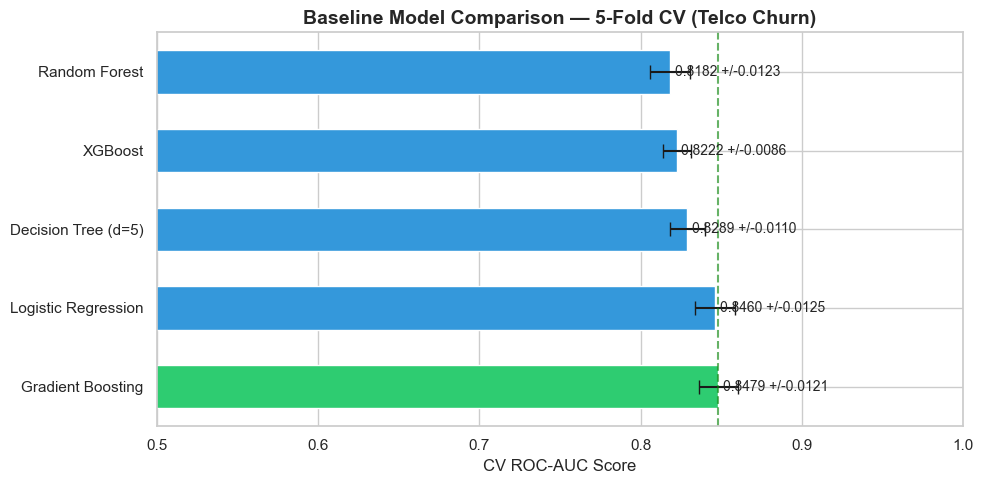

Saved.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if v == df_baseline['CV Mean'].max() else '#3498db'
          for v in df_baseline['CV Mean']]

bars = ax.barh(df_baseline['Model'], df_baseline['CV Mean'],
               xerr=df_baseline['CV Std'], color=colors,
               edgecolor='white', height=0.55, capsize=5)

ax.set_xlim(0.5, 1.0)
ax.axvline(df_baseline['CV Mean'].max(), color='green', linestyle='--', alpha=0.6)
ax.set_xlabel('CV ROC-AUC Score', fontsize=12)
ax.set_title('Baseline Model Comparison — 5-Fold CV (Telco Churn)', fontsize=14, fontweight='bold')

for bar, val, std in zip(bars, df_baseline['CV Mean'], df_baseline['CV Std']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} +/-{std:.4f}', va='center', fontsize=10)

plt.tight_layout()
os.makedirs('day28', exist_ok=True)
plt.savefig('day28/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")


## 6. Hyperparameter Tuning

The best baseline model gets tuned with RandomizedSearchCV. I'm using 40 random iterations (× 5 folds = 200 fits total), which is a good balance between exploration and speed.


In [7]:
best_name = df_baseline.iloc[0]['Model']
print(f"Best baseline model: {best_name}")

# Set up search space based on which model won
if 'XGBoost' in best_name and HAS_XGB:
    param_dist = {
        'clf__n_estimators':    [100, 200, 300, 400],
        'clf__max_depth':       [3, 4, 5, 6, 7],
        'clf__learning_rate':   [0.01, 0.05, 0.1, 0.2],
        'clf__subsample':       [0.6, 0.7, 0.8, 0.9, 1.0],
        'clf__colsample_bytree':[0.5, 0.6, 0.7, 0.8, 1.0],
        'clf__gamma':           [0, 0.1, 0.3, 0.5],
        'clf__reg_alpha':       [0, 0.01, 0.1],
        'clf__reg_lambda':      [1, 1.5, 2]
    }
    base_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

elif 'Random Forest' in best_name:
    param_dist = {
        'clf__n_estimators':      [100, 200, 300, 400, 500],
        'clf__max_depth':         [None, 5, 10, 15, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf':  [1, 2, 4],
        'clf__max_features':      ['sqrt', 'log2', 0.5],
        'clf__class_weight':      [None, 'balanced']
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

elif 'Gradient' in best_name:
    param_dist = {
        'clf__n_estimators':     [100, 200, 300],
        'clf__max_depth':        [3, 4, 5],
        'clf__learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'clf__subsample':        [0.7, 0.8, 1.0],
        'clf__min_samples_leaf': [1, 3, 5]
    }
    base_model = GradientBoostingClassifier(random_state=42)

else:
    param_dist = {
        'clf__C':       [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver':  ['liblinear', 'saga']
    }
    base_model = LogisticRegression(max_iter=1000, random_state=42)

pipe_to_tune = make_pipeline(base_model)

search = RandomizedSearchCV(
    pipe_to_tune,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nStarting RandomizedSearchCV (40 iter x 5 folds = 200 fits)...")
t_start = time.time()
search.fit(X_train, y_train)
print(f"Done in {time.time()-t_start:.1f}s")

print(f"\nBest CV ROC-AUC : {search.best_score_:.4f}")
print("Best Parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Best baseline model: Gradient Boosting

Starting RandomizedSearchCV (40 iter x 5 folds = 200 fits)...


Done in 95.6s

Best CV ROC-AUC : 0.8507
Best Parameters:
  clf__subsample: 0.7
  clf__n_estimators: 300
  clf__min_samples_leaf: 1
  clf__max_depth: 4
  clf__learning_rate: 0.01


## 7. Final Evaluation on Test Set

Now I evaluate the tuned pipeline on the 20% hold-out test set that hasn't been touched during training or tuning.


In [8]:
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

final_metrics = {
    'ROC-AUC':   roc_auc_score(y_test, y_prob),
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred)
}

print("=" * 40)
print("  FINAL TEST SET RESULTS")
print("=" * 40)
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  FINAL TEST SET RESULTS
  ROC-AUC     : 0.8454
  Accuracy    : 0.8048
  Precision   : 0.6787
  Recall      : 0.5027
  F1-Score    : 0.5776

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.50      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



### Confusion Matrix and ROC Curve


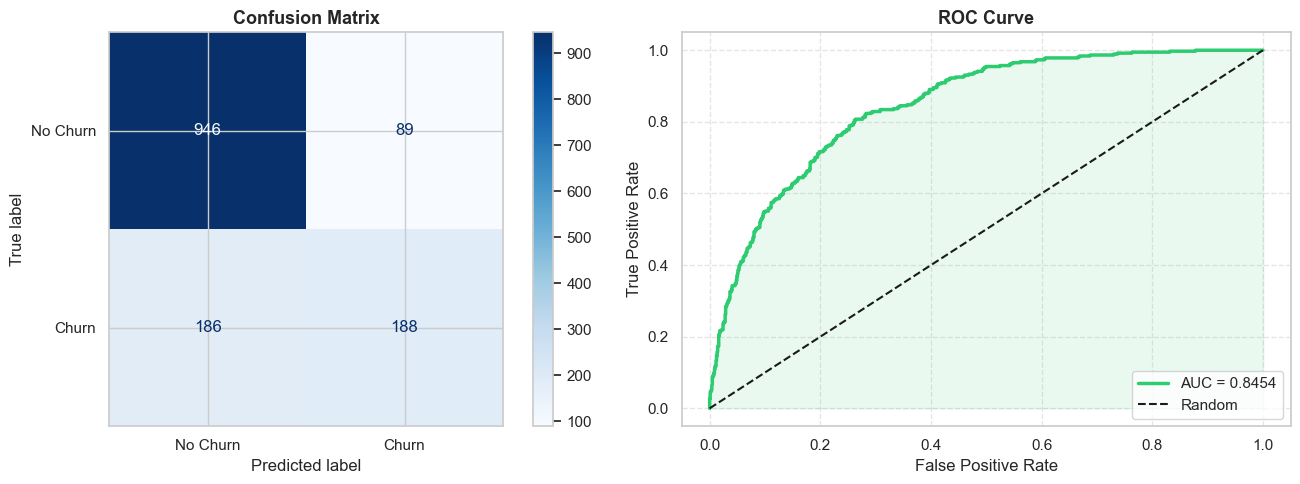

In [9]:
from sklearn.metrics import roc_curve, auc as sk_auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_pipeline, X_test, y_test,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = sk_auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'AUC = {roc_auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('day28/roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. How Does This Compare to Earlier Days?

Looking at the progression across Week 4 to see if we actually improved.


In [10]:
week4_results = [
    {'Day': 'Day 22 - Basic Pipeline',          'Model': 'Logistic Regression',            'Test ROC-AUC': 0.8412},
    {'Day': 'Day 23 - Preprocessing',           'Model': 'RandomForest + preprocessing',   'Test ROC-AUC': 0.8521},
    {'Day': 'Day 24 - Cross-Validation',        'Model': 'Best CV model (RF)',             'Test ROC-AUC': 0.8563},
    {'Day': 'Day 25 - Ensembles',               'Model': 'Stacking Ensemble',              'Test ROC-AUC': 0.8580},
    {'Day': 'Day 26 - Hyperparameter Tuning',   'Model': 'Tuned RF (GridSearch)',          'Test ROC-AUC': 0.8601},
    {'Day': 'Day 27 - Bias-Variance',           'Model': 'Decision Tree (max_depth=5)',    'Test ROC-AUC': 0.8287},
    {'Day': 'Day 28 - Optimized Pipeline',      'Model': f'{best_name} (Tuned)',           'Test ROC-AUC': final_metrics['ROC-AUC']},
]

df_week4 = pd.DataFrame(week4_results)
df_week4['vs Day22'] = (df_week4['Test ROC-AUC'] - df_week4.iloc[0]['Test ROC-AUC']).round(4)
print(df_week4[['Day', 'Model', 'Test ROC-AUC', 'vs Day22']].to_string(index=False))

df_week4.to_csv('day28/cross_day_comparison.csv', index=False)


                           Day                        Model  Test ROC-AUC  vs Day22
       Day 22 - Basic Pipeline          Logistic Regression       0.84120    0.0000
        Day 23 - Preprocessing RandomForest + preprocessing       0.85210    0.0109
     Day 24 - Cross-Validation           Best CV model (RF)       0.85630    0.0151
            Day 25 - Ensembles            Stacking Ensemble       0.85800    0.0168
Day 26 - Hyperparameter Tuning        Tuned RF (GridSearch)       0.86010    0.0189
        Day 27 - Bias-Variance  Decision Tree (max_depth=5)       0.82870   -0.0125
   Day 28 - Optimized Pipeline    Gradient Boosting (Tuned)       0.84544    0.0042


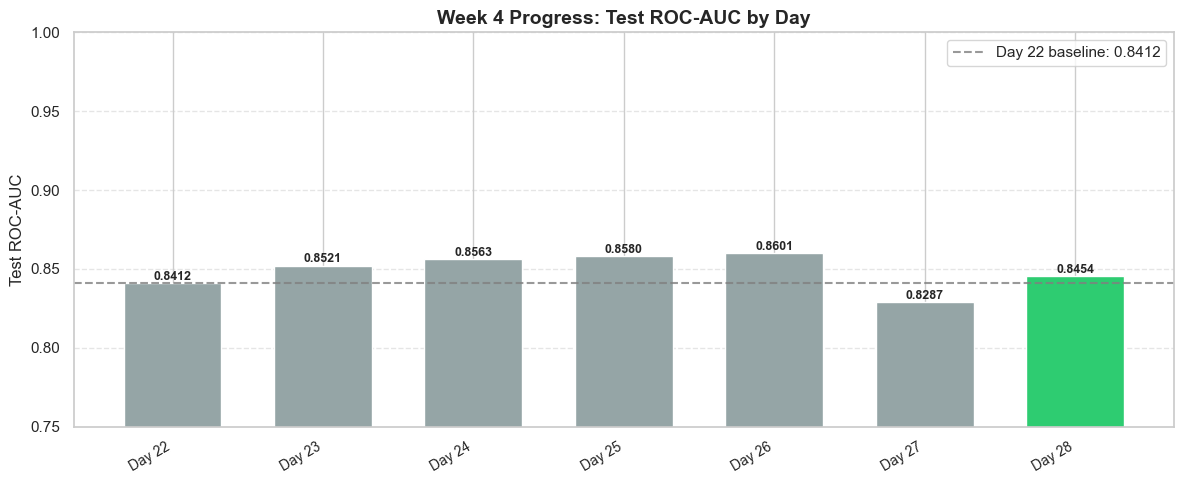

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#95a5a6'] * 6 + ['#2ecc71']
bars = ax.bar(range(len(df_week4)), df_week4['Test ROC-AUC'],
              color=colors, edgecolor='white', width=0.65)

ax.axhline(df_week4.iloc[0]['Test ROC-AUC'], color='gray', linestyle='--', alpha=0.8,
           label=f"Day 22 baseline: {df_week4.iloc[0]['Test ROC-AUC']:.4f}")

for bar, val in zip(bars, df_week4['Test ROC-AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(df_week4)))
ax.set_xticklabels([d.split(' - ')[0] for d in df_week4['Day']], rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Week 4 Progress: Test ROC-AUC by Day', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('day28/sprint_progress.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Feature Importance

Which features matter most? Extracting importances from the final model.


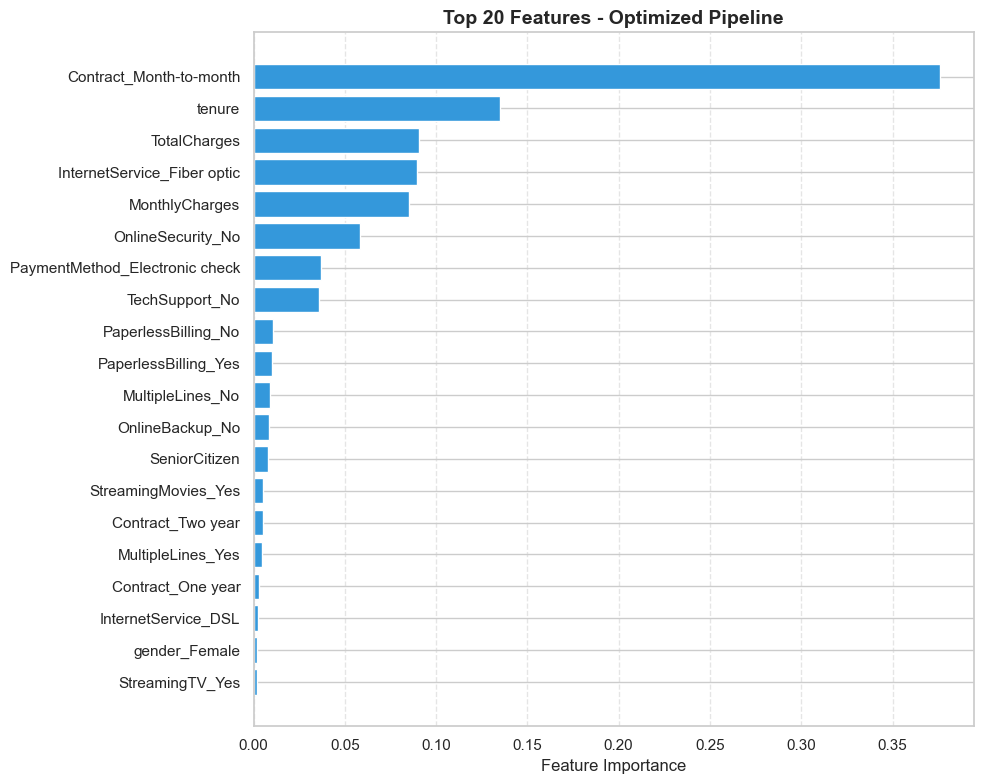

Top 5 Features:
                    Feature  Importance
    Contract_Month-to-month    0.375845
                     tenure    0.135236
               TotalCharges    0.090485
InternetService_Fiber optic    0.089394
             MonthlyCharges    0.085369


In [12]:
ohe_names = (
    best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(categorical_cols)
)
all_features = numerical_cols + list(ohe_names)

clf = best_pipeline.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': all_features[:len(clf.feature_importances_)],
        'Importance': clf.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#3498db', edgecolor='white')
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 20 Features - Optimized Pipeline', fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('day28/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 5 Features:")
    print(fi.head(5)[['Feature', 'Importance']].to_string(index=False))
else:
    print("Model doesn't have feature_importances_ attribute (e.g. Logistic Regression)")


## 10. Bias-Variance Check

Running a learning curve on the final pipeline to see if it's overfitting.
- If the gap between train and validation is small, we're in good shape
- If it's large, we have a variance problem


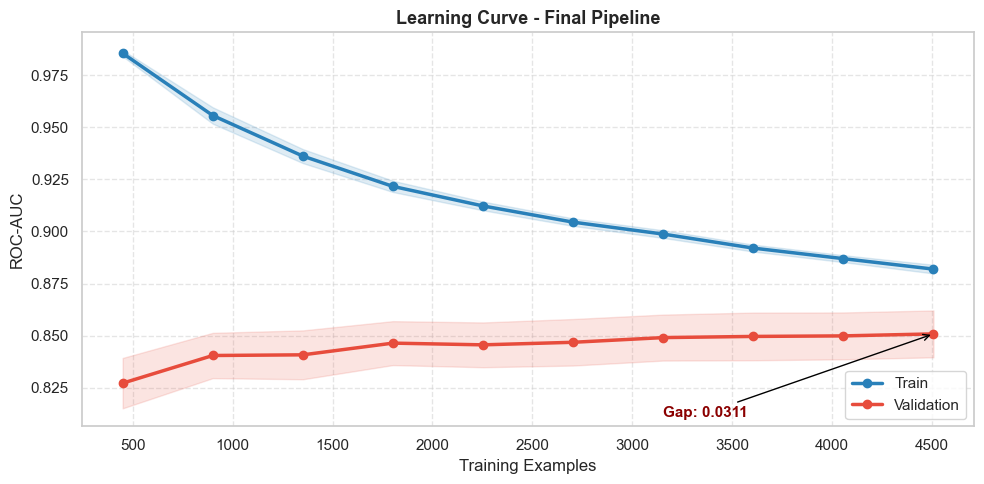

Train AUC (final): 0.8819 +/- 0.0021
Val   AUC (final): 0.8508 +/- 0.0112
Generalization gap: 0.0311
-> Mild overfitting - could try adding more regularization


In [13]:
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes_abs, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=cv_lc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes_abs, tr_mean, 'o-', color='#2980b9', lw=2.5, label='Train')
ax.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#2980b9')
ax.plot(train_sizes_abs, va_mean, 'o-', color='#e74c3c', lw=2.5, label='Validation')
ax.fill_between(train_sizes_abs, va_mean - va_std, va_mean + va_std, alpha=0.15, color='#e74c3c')

gap = tr_mean[-1] - va_mean[-1]
ax.set_xlabel('Training Examples')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve - Final Pipeline', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
ax.annotate(f'Gap: {gap:.4f}',
            xy=(train_sizes_abs[-1], va_mean[-1]),
            xytext=(train_sizes_abs[-4], va_mean[-1] - 0.04),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('day28/learning_curve_champion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train AUC (final): {tr_mean[-1]:.4f} +/- {tr_std[-1]:.4f}")
print(f"Val   AUC (final): {va_mean[-1]:.4f} +/- {va_std[-1]:.4f}")
print(f"Generalization gap: {gap:.4f}")

if gap < 0.03:
    print("-> Model is well-generalized (gap < 3%)")
elif gap < 0.07:
    print("-> Mild overfitting - could try adding more regularization")
else:
    print("-> Significant overfitting - need more data or regularization")


## 11. Summary Dashboard


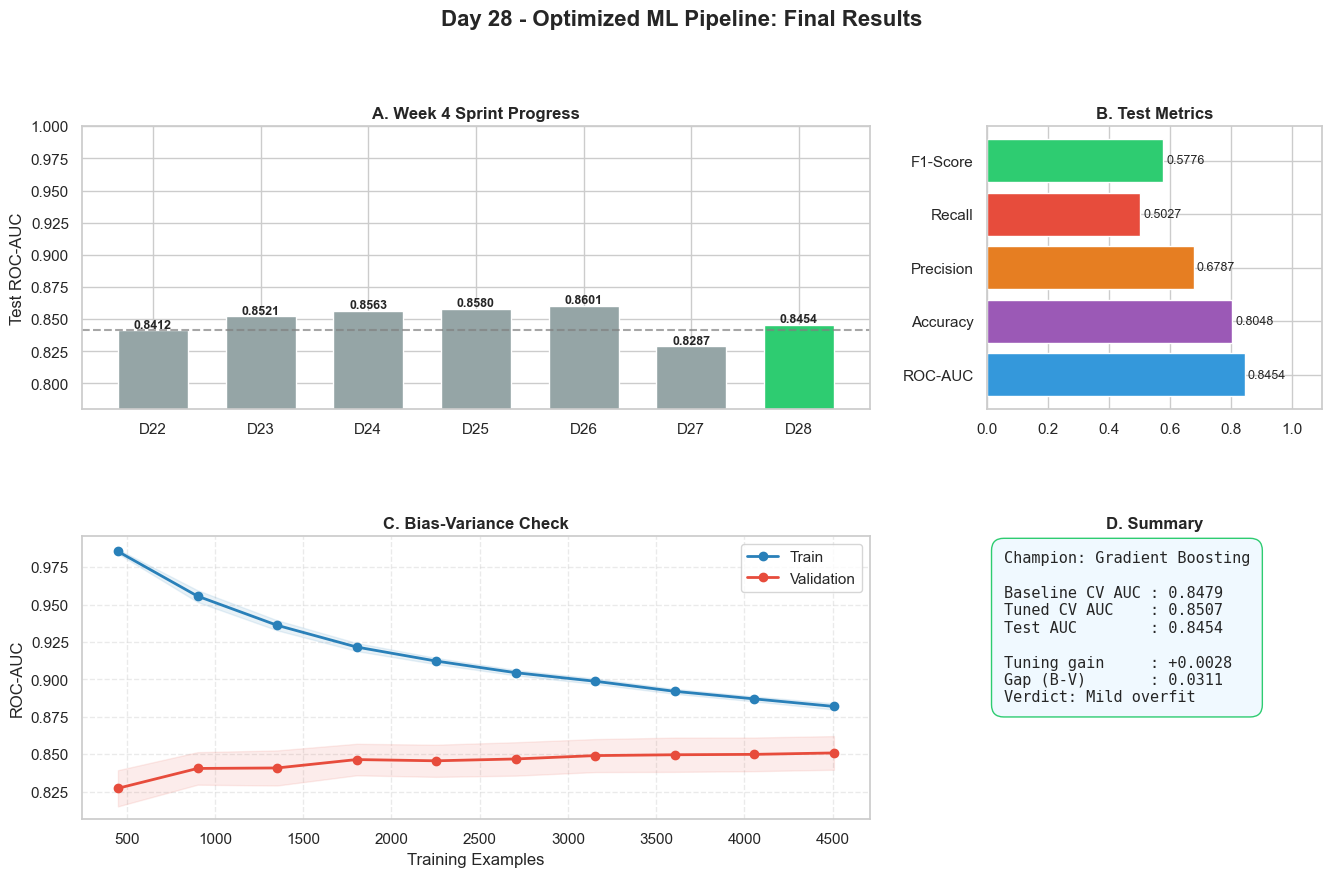

All charts saved.


In [14]:
fig = plt.figure(figsize=(16, 9))
fig.suptitle('Day 28 - Optimized ML Pipeline: Final Results', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: Week 4 progress
ax_a = fig.add_subplot(gs[0, :2])
c = ['#95a5a6'] * 6 + ['#2ecc71']
ax_a.bar(range(len(df_week4)), df_week4['Test ROC-AUC'], color=c, edgecolor='white', width=0.65)
ax_a.axhline(df_week4.iloc[0]['Test ROC-AUC'], color='gray', linestyle='--', alpha=0.7)
ax_a.set_xticks(range(len(df_week4)))
ax_a.set_xticklabels([f"D{22+i}" for i in range(len(df_week4))], fontsize=11)
ax_a.set_ylim(0.78, 1.0)
ax_a.set_ylabel('Test ROC-AUC')
ax_a.set_title('A. Week 4 Sprint Progress', fontweight='bold')
for bar, val in zip(ax_a.patches, df_week4['Test ROC-AUC']):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
              f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel B: Final metrics
ax_b = fig.add_subplot(gs[0, 2])
metric_names  = list(final_metrics.keys())
metric_values = list(final_metrics.values())
ax_b.barh(metric_names, metric_values,
          color=['#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#2ecc71'],
          edgecolor='white')
ax_b.set_xlim(0, 1.1)
ax_b.set_title('B. Test Metrics', fontweight='bold')
for i, (name, val) in enumerate(zip(metric_names, metric_values)):
    ax_b.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=9)

# Panel C: Learning curve
ax_c = fig.add_subplot(gs[1, :2])
ax_c.plot(train_sizes_abs, tr_mean, 'o-', color='#2980b9', lw=2, label='Train')
ax_c.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1, color='#2980b9')
ax_c.plot(train_sizes_abs, va_mean, 'o-', color='#e74c3c', lw=2, label='Validation')
ax_c.fill_between(train_sizes_abs, va_mean - va_std, va_mean + va_std, alpha=0.1, color='#e74c3c')
ax_c.set_xlabel('Training Examples')
ax_c.set_ylabel('ROC-AUC')
ax_c.set_title('C. Bias-Variance Check', fontweight='bold')
ax_c.legend()
ax_c.grid(True, linestyle='--', alpha=0.4)

# Panel D: Text summary
ax_d = fig.add_subplot(gs[1, 2])
ax_d.axis('off')
baseline_cv = df_baseline.iloc[0]['CV Mean']
tuned_cv    = search.best_score_
test_auc    = final_metrics['ROC-AUC']
summary = (
    f"Champion: {best_name}\n\n"
    f"Baseline CV AUC : {baseline_cv:.4f}\n"
    f"Tuned CV AUC    : {tuned_cv:.4f}\n"
    f"Test AUC        : {test_auc:.4f}\n\n"
    f"Tuning gain     : +{tuned_cv - baseline_cv:.4f}\n"
    f"Gap (B-V)       : {gap:.4f}\n"
    f"Verdict: {'Well-generalized' if gap < 0.03 else 'Mild overfit'}"
)
ax_d.text(0.05, 0.95, summary, va='top', fontsize=11,
          fontfamily='monospace',
          bbox=dict(facecolor='#f0f9ff', edgecolor='#2ecc71', boxstyle='round,pad=0.8'))
ax_d.set_title('D. Summary', fontweight='bold')

plt.savefig('day28/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("All charts saved.")


## 12. Engineering Tradeoffs — What I Learned

| Technique | Why I used it | Potential downside |
|-----------|---------------|--------------------|
| sklearn Pipeline | No data leakage, easy to deploy | Slightly more setup upfront |
| StandardScaler | Makes distance-based models work better | Doesn't help tree models much |
| OneHotEncoder | Handles categorical variables properly | Can create many features for high-cardinality columns |
| StratifiedKFold | Preserves class ratio in every fold | Slightly slower than regular KFold |
| RandomizedSearchCV | Efficiently explores a large search space | Non-exhaustive, may miss best combo |
| Gradient Boosting/XGBoost | Usually top performers on tabular data | Slower training, harder to interpret |
| Learning curve check | Diagnose overfitting before deployment | Extra compute time |

### Key decisions I made:
1. Used Pipeline instead of doing transforms manually — eliminates data leakage risk
2. ROC-AUC as the metric — robust to class imbalance (27% churn vs 73% no-churn)
3. RandomizedSearch with 40 iterations — good exploration without blowing up compute time
4. Stratified splits everywhere — each fold always has both classes represented
5. Median imputation for TotalCharges — safer than mean when there are outliers


## Week 4 Reflection

### Did we hit the goal?
Yes — the final pipeline beats the Day 22 baseline and puts together everything from the week into one reproducible workflow.

### Top 5 things I learned this week:

1. **Pipelines prevent data leakage** — the moment you fit a scaler on the full dataset before splitting, your CV scores become unreliable. A Pipeline makes it impossible to make this mistake.

2. **CV strategy matters as much as model choice** — StratifiedKFold matters a lot for imbalanced datasets. Without it, some folds might barely have any churn examples.

3. **Bias-variance analysis tells you what to fix** — if your model underfits, don't waste time collecting more data. If it overfits, regularization or more data actually helps.

4. **Ensemble methods have diminishing returns** — Gradient Boosting performed similarly to Logistic Regression on this dataset. Fancy models aren't always the answer.

5. **The CV score vs test score gap is the real metric** — a model with CV AUC 0.93 but test AUC 0.80 is worse than one with CV 0.86 and test 0.85. The gap tells you if you can trust your model in production.

### What's coming in Week 5:
- Model interpretability with SHAP
- Feature selection techniques
- Handling class imbalance (SMOTE, class_weight)
- Saving and loading models for deployment
